In [3]:
# =========================================
# 3.2 Data Cleaning — make issues explicit, then resolve
# Inputs (from 3.1): prep_outputs/final_selected_table.csv
# Outputs:
#   prep_outputs/cleaning_issues.csv
#   prep_outputs/cleaning_summary.csv
#   prep_outputs/final_selected_table_clean.csv
#   prep_outputs/final_selected_table_imputed.csv
#   prep_outputs/cleaning_rules_snapshot.json
#   prep_outputs/cleaning_summary_table.csv
#   figs/*.png
# =========================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 0) Paths, constants, helpers
# ---------------------------
OUT_DIR = Path("prep_outputs"); OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = Path("figs");         FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name: str, **kwargs):
    """Save current figure to figs/ with consistent options."""
    path = FIG_DIR / name
    plt.savefig(path, dpi=200, bbox_inches="tight", **kwargs)
    print(f"[Saved] {path}")

SRC_SELECTED = OUT_DIR / "final_selected_table.csv"
TARGET_COL   = "AMIGR"    # do not impute target
ID_COL       = "RID"      # row id

# Load 3.1 selected table
df_raw = pd.read_csv(SRC_SELECTED)
print("Loaded:", SRC_SELECTED, "| shape:", df_raw.shape)

Loaded: prep_outputs/final_selected_table.csv | shape: (25417, 54)


In [6]:
# ---------------------------
# 1) Declare cleaning rules
# ---------------------------

# NHIS-style non-substantive codes
BAD_CAT     = {7, 8, 9}              # Refused / Not ascertained / Don't know
BAD_CAT_EXT = BAD_CAT | {97, 98, 99}
BMI_MISS    = {9999}

EXPLICIT_RULES = {
    # Binary yes/no with 7/8/9 missing
    "AMIGR":   {"missing_codes": BAD_CAT},
    "HYPEV":   {"missing_codes": BAD_CAT},
    "CHDEV":   {"missing_codes": BAD_CAT},
    "MIEV":    {"missing_codes": BAD_CAT},
    "HRTEV":   {"missing_codes": BAD_CAT},
    "CANEV":   {"missing_codes": BAD_CAT},
    "AHAYFYR": {"missing_codes": BAD_CAT},
    "AHCSYR1": {"missing_codes": BAD_CAT},
    "PAINLB":  {"missing_codes": BAD_CAT},
    "PAINFACE":{"missing_codes": BAD_CAT},
    "SINYR":   {"missing_codes": BAD_CAT},
    "ANX_2":   {"missing_codes": BAD_CAT},
    "DEP_2":   {"missing_codes": BAD_CAT},
    "ARX12_2": {"missing_codes": BAD_CAT},
    "ARX12_3": {"missing_codes": BAD_CAT},
    "ASIHIVT": {"missing_codes": BAD_CAT},
    "ASPONOWN": {"missing_codes": BAD_CAT},
    "DIBPRE2": {"missing_codes": BAD_CAT},
    "JNTSYMP": {"missing_codes": BAD_CAT},
    "PAINECK": {"missing_codes": BAD_CAT},

    # Ordinals with valid range + 7/8/9 missing
    "DEP_1":   {"missing_codes": BAD_CAT, "valid_range": (1, 5)},
    "ANX_1":   {"missing_codes": BAD_CAT, "valid_range": (1, 5)},
    "ASIEFFRT": {"missing_codes": BAD_CAT, "valid_range": (1, 5)},
    "ASIRSTLS": {"missing_codes": BAD_CAT, "valid_range": (1, 5)},
    "ASISAD": {"missing_codes": BAD_CAT, "valid_range": (1, 5)},
    "ASIHOPLS": {"missing_codes": BAD_CAT, "valid_range": (1, 5)},
    "ASINERVE": {"missing_codes": BAD_CAT, "valid_range": (1, 5)},
    "ASIWTHLS": {"missing_codes": BAD_CAT, "valid_range": (1, 5)},
    "TIRED_1": {"missing_codes": BAD_CAT, "valid_range": (1, 4)},
    "ASIMEDC": {"missing_codes": BAD_CAT, "valid_range": (1, 4)},
    "ASIRETR": {"missing_codes": BAD_CAT, "valid_range": (1, 4)},
    "ASINBILL": {"missing_codes": BAD_CAT, "valid_range": (1, 4)},
    "ASIMUCH": {"missing_codes": BAD_CAT, "valid_range": (1, 4)},
    "TIRED_2": {"missing_codes": BAD_CAT, "valid_range": (1, 3)},
    "SMKNOW": {"missing_codes": BAD_CAT, "valid_range": (1, 3)},
    "AWORPAY": {"missing_codes": BAD_CAT, "valid_range": (1, 3)},
    "TIRED_3": {"missing_codes": BAD_CAT, "valid_range": (1, 3)},
    "PAIN_2A": {"missing_codes": BAD_CAT, "valid_range": (1, 4)},
    "PAIN_4":  {"missing_codes": BAD_CAT, "valid_range": (1, 3)},
    "ANX_3R":  {"missing_codes": BAD_CAT, "valid_range": (1, 3)},

    # Multi-level categoricals
    "SMKSTAT2": {"missing_codes": BAD_CAT | {9}},
    "ALCSTAT":  {"missing_codes": BAD_CAT | {10}},
    "ALC12MTP": {"missing_codes": BAD_CAT},
    "DOINGLWA": {"missing_codes": BAD_CAT},
    "REGION":   {"missing_codes": set()},
    "R_MARITL": {"missing_codes": BAD_CAT},
    "HISPAN_I": {"missing_codes": BAD_CAT},
    "RACERPI2": {"missing_codes": BAD_CAT},

    # Continuous with special encodings
    "AGE_P":     {"clip_range": (18, 85)},                               # 85 top-coded
    "BMI":       {"missing_codes": BMI_MISS, "scale": 0.01, "plausible_range": (10, 80)},
    "ASISLEEP":  {"missing_codes": {97, 98, 99}, "clip_range": (1, 24)}, # hours/24h
    "YRSWRKPA":  {"missing_codes": {97, 98, 99}, "clip_range": (0, 35)}, # 35=35+
    "ALC12MYR":  {"missing_codes": {997, 998, 999}, "clip_range": (0, 366)},
    "BEDDAYR":   {"missing_codes": {997, 998, 999}, "clip_range": (0, 366)},
    "WKDAYR":   {"missing_codes": {997, 998, 999}, "clip_range": (0, 366)},
}

# Fallback: treat as coded categorical only if >50% of unique values look like codes
CODE_UNIVERSE      = set(range(1, 10)) | {97, 98, 99, 9999}
FALLBACK_THRESHOLD = 0.5

In [7]:
# ---------------------------
# 2) Utilities
# ---------------------------
def inspect_column(s: pd.Series, name: str) -> dict:
    """Collect issues BEFORE cleaning."""
    vals = pd.Series(s.dropna().unique())
    share_in_codes = float(vals.isin(CODE_UNIVERSE).mean()) if len(vals) else 0.0

    issues = {
        "col": name,
        "dtype": str(s.dtype),
        "n": int(s.shape[0]),
        "n_na_raw": int(s.isna().sum()),
        "n_unique_raw": int(s.nunique(dropna=True)),
        "share_codes_like": share_in_codes,
    }
    rule = EXPLICIT_RULES.get(name, {})
    if "missing_codes"   in rule: issues["n_bad_codes"]       = int(s.isin(rule["missing_codes"]).sum())
    if "valid_range"     in rule: 
        lo, hi = rule["valid_range"];   issues["n_out_of_valid"]     = int(((s < lo) | (s > hi)).sum(skipna=True))
    if "clip_range"      in rule: 
        lo, hi = rule["clip_range"];    issues["n_out_of_clip"]      = int(((s < lo) | (s > hi)).sum(skipna=True))
    if "plausible_range" in rule: 
        lo, hi = rule["plausible_range"]; issues["n_out_of_plausible"] = int(((s < lo) | (s > hi)).sum(skipna=True))
    return issues

def clean_column(s: pd.Series, name: str) -> pd.Series:
    """Apply explicit rule; else conservative fallback for coded categoricals."""
    x = s.copy()
    rule = EXPLICIT_RULES.get(name)
    if rule is not None:
        if "missing_codes" in rule:
            x = x.where(~x.isin(rule["missing_codes"]), np.nan)
        if "scale" in rule:
            x = x.astype("float64") * rule["scale"]
        if "clip_range" in rule:
            lo, hi = rule["clip_range"]; x = x.where(~((x < lo) | (x > hi)), np.nan)
        if "plausible_range" in rule:
            lo, hi = rule["plausible_range"]; x = x.where(~((x < lo) | (x > hi)), np.nan)
        return x

    uniq = pd.Series(x.dropna().unique())
    share_in_codes = float(uniq.isin(CODE_UNIVERSE).mean()) if len(uniq) else 0.0
    if share_in_codes > FALLBACK_THRESHOLD:
        x = x.where(~x.isin(BAD_CAT_EXT), np.nan)
    return x

def try_cast_nullable_int(series: pd.Series) -> pd.Series:
    """Cast float columns with integer-like values to pandas nullable Int64."""
    if pd.api.types.is_float_dtype(series):
        s_non_na = series.dropna()
        if len(s_non_na) and np.all(np.mod(s_non_na, 1) == 0):
            return series.astype("Int64")
    return series

In [8]:
# ---------------------------
# 3) Make issues explicit
# ---------------------------
issues = []
for c in df_raw.columns:
    if c == ID_COL: 
        continue
    issues.append(inspect_column(df_raw[c], c))

issues_df = pd.DataFrame(issues).sort_values(
    ["n_bad_codes", "n_out_of_plausible", "n_out_of_clip", "share_codes_like"],
    ascending=False
)
issues_df.to_csv(OUT_DIR / "cleaning_issues.csv", index=False)
print("Saved ->", OUT_DIR / "cleaning_issues.csv")

Saved -> prep_outputs/cleaning_issues.csv


In [9]:
# ---------------------------
# 4) Apply cleaning rules -> df_clean
# ---------------------------
df_clean = df_raw.copy()

before = {
    c: {"n_na": int(df_raw[c].isna().sum()), "n_unique": int(df_raw[c].nunique(dropna=True))}
    for c in df_raw.columns if c != ID_COL
}

for c in df_clean.columns:
    if c == ID_COL: 
        continue
    df_clean[c] = clean_column(df_clean[c], c)

after = {
    c: {"n_na": int(df_clean[c].isna().sum()), "n_unique": int(df_clean[c].nunique(dropna=True))}
    for c in df_clean.columns if c != ID_COL
}

summary_rows = []
for c in [col for col in df_clean.columns if col != ID_COL]:
    summary_rows.append({
        "col": c,
        "n_na_before": before[c]["n_na"],
        "n_na_after":  after[c]["n_na"],
        "delta_na":    after[c]["n_na"] - before[c]["n_na"],
        "unique_before": before[c]["n_unique"],
        "unique_after":  after[c]["n_unique"],
    })
pd.DataFrame(summary_rows).sort_values("delta_na", ascending=False)\
  .to_csv(OUT_DIR / "cleaning_summary.csv", index=False)
print("Saved ->", OUT_DIR / "cleaning_summary.csv")

# Cast integer-like floats back to Int64 (nullable)
for c in df_clean.columns:
    if c != ID_COL:
        df_clean[c] = try_cast_nullable_int(df_clean[c])

# Save cleaned table with NaNs for imputation step
CLEAN_CSV = OUT_DIR / "final_selected_table_clean.csv"
df_clean.to_csv(CLEAN_CSV, index=False)
print("Saved cleaned table ->", CLEAN_CSV, "| shape:", df_clean.shape)

# Rules snapshot (for reproducibility)
rules_snapshot = {
    "explicit_rules": {k: {kk: list(v) if isinstance(v, set) else v
                           for kk, v in EXPLICIT_RULES[k].items()}
                       for k in EXPLICIT_RULES},
    "fallback_threshold": FALLBACK_THRESHOLD,
    "code_universe": sorted(CODE_UNIVERSE),
}
with open(OUT_DIR / "cleaning_rules_snapshot.json", "w") as f:
    json.dump(rules_snapshot, f, indent=2)
print("Saved ->", OUT_DIR / "cleaning_rules_snapshot.json")

Saved -> prep_outputs/cleaning_summary.csv
Saved cleaned table -> prep_outputs/final_selected_table_clean.csv | shape: (25417, 54)
Saved -> prep_outputs/cleaning_rules_snapshot.json


[Saved] figs/missing_counts.png


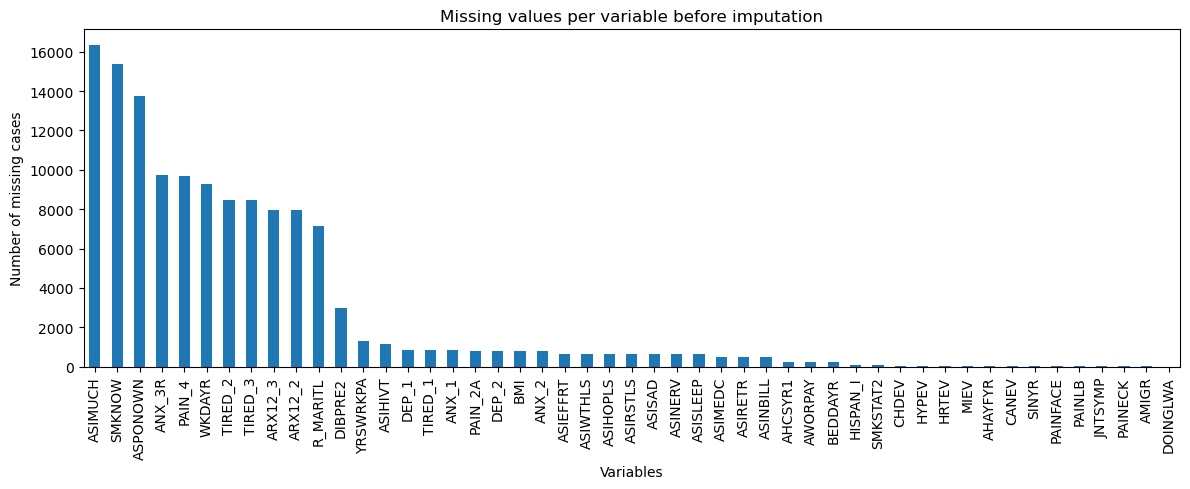

[Saved] figs/missing_ratio.png


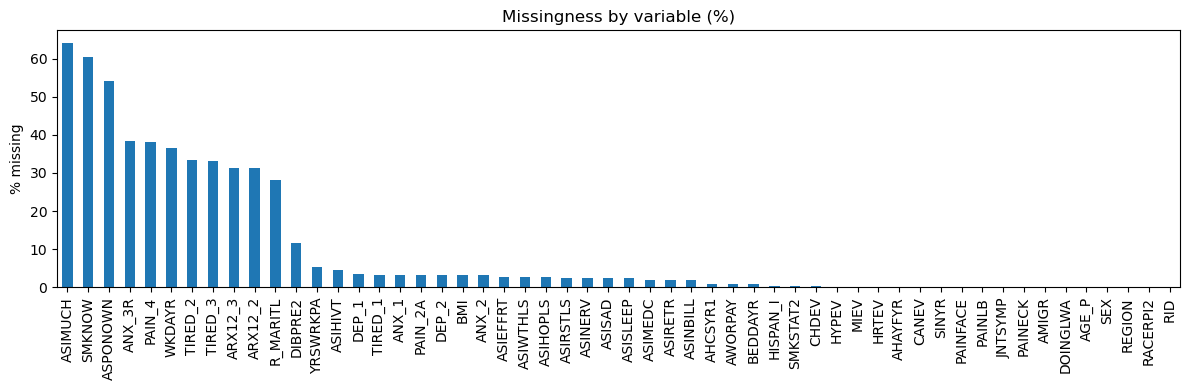

In [10]:
# ---------------------------
# 5) Figures — missingness (after cleaning, before imputation)
# ---------------------------
miss_ct = df_clean.isna().sum()
miss_ct = miss_ct[miss_ct > 0].sort_values(ascending=False)

plt.figure(figsize=(12,5))
miss_ct.plot(kind='bar')
plt.title("Missing values per variable before imputation")
plt.ylabel("Number of missing cases"); plt.xlabel("Variables")
plt.tight_layout(); savefig("missing_counts.png"); plt.show()

ax = (df_clean.isna().mean().sort_values(ascending=False) * 100).plot.bar(figsize=(12,4))
ax.set_title("Missingness by variable (%)")
ax.set_ylabel("% missing")
plt.tight_layout(); savefig("missing_ratio.png"); plt.show()

In [11]:
# ===========================================================
# PHASE 2 — Imputation & Outlier handling (df_imp)
# ===========================================================
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

# Work on a fresh copy
df_imp = df_clean.copy()

# Drop all-NaN columns
all_nan_cols = df_imp.columns[df_imp.isna().all()].tolist()
if all_nan_cols:
    print(f"Dropping all-NaN columns: {all_nan_cols}")
    df_imp = df_imp.drop(columns=all_nan_cols)

# (Optional) drop variables with extremely high missingness (>50%)
miss_ratio = df_imp.isna().mean()
high_missing_cols = miss_ratio[miss_ratio > 0.5].index.tolist()
if high_missing_cols:
    print(f"Dropping high-missing columns (>50%): {high_missing_cols}")
    df_imp = df_imp.drop(columns=high_missing_cols)

# Buckets
KNOWN_CONTINUOUS = {"AGE_P", "BMI", "ASISLEEP", "WKDAYR", "MODMIN"}
INT_COUNT_RANGES = { "ALC12MYR": (0, 365), "YRSWRKPA": (0, 35), "BEDDAYR": (0, 365) }
LOCK_LOW_CARD_NUMERIC = {"DOINGLWA", "PAINECK"}  # force back to integer codes later

def infer_categoricals(frame: pd.DataFrame, max_card: int = 15):
    cat_cols, allowed_codes = [], {}
    for c in frame.columns:
        if c in {TARGET_COL, ID_COL} or c in INT_COUNT_RANGES or c in KNOWN_CONTINUOUS:
            continue
        s = frame[c].dropna()
        if s.empty: 
            continue
        if s.dtype == "object" or pd.api.types.is_categorical_dtype(s):
            cat_cols.append(c); allowed_codes[c] = sorted(pd.unique(s)); continue
        nunique = s.nunique(dropna=True); vals = s.unique()
        if nunique <= max_card and np.all(np.isclose(vals, np.round(vals), atol=1e-8)):
            cat_cols.append(c); allowed_codes[c] = sorted(int(round(v)) for v in vals)
    cat_cols = sorted(set(cat_cols))
    num_cols = [c for c in frame.columns
                if pd.api.types.is_numeric_dtype(frame[c])
                and c not in cat_cols and c not in {TARGET_COL, ID_COL} and c not in INT_COUNT_RANGES]
    for k in KNOWN_CONTINUOUS:
        if k in frame.columns and k not in num_cols and k not in {TARGET_COL, ID_COL}:
            num_cols.append(k)
    return cat_cols, sorted(set(num_cols)), allowed_codes

cat_cols, num_cols, allowed_codes = infer_categoricals(df_imp, max_card=15)
print(f"Inferred categorical (sample): {cat_cols[:8]}")
print(f"Numeric (sample): {num_cols[:8]}")
print("Integer-count with ranges:", list(INT_COUNT_RANGES.keys()))

# Snapshot for "before imputation" plots
snap_cols = [c for c in ["BMI","ASISLEEP","BEDDAYR","ALC12MYR","YRSWRKPA"] if c in df_imp.columns]
df_before_imp = df_imp[snap_cols].copy()

# 1) Categorical imputation (most frequent)
if cat_cols:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    df_imp[cat_cols] = cat_imputer.fit_transform(df_imp[cat_cols])

# 2) Integer-count imputation: KNN -> round -> clamp
for col, (lo, hi) in INT_COUNT_RANGES.items():
    if col not in df_imp.columns:
        print(f"{col}: not found; skipped."); continue
    s = df_imp[col]
    if s.notna().sum() == 0:
        df_imp[col] = int(lo); print(f"{col}: all NaN -> filled with {lo}."); continue
    knn = KNNImputer(n_neighbors=5)
    imputed = knn.fit_transform(s.to_frame().astype(float))
    arr = np.rint(imputed[:, 0]).astype(np.int64)
    arr = np.clip(arr, lo, hi)
    df_imp[col] = pd.Series(arr, index=df_imp.index).astype(np.int64)
    print(f"{col}: KNN imputed, rounded, clamped [{lo},{hi}].")

# 3) Numeric imputation (MICE-like)
if num_cols:
    iter_imp = IterativeImputer(random_state=42, max_iter=10, sample_posterior=False, initial_strategy="median")
    df_imp[num_cols] = iter_imp.fit_transform(df_imp[num_cols])

# 4) Re-round low-card numeric codes back to ints
for c in LOCK_LOW_CARD_NUMERIC:
    if c in df_imp.columns:
        s = pd.to_numeric(df_imp[c], errors="coerce")
        df_imp[c] = np.rint(s).astype("Int64")
        print(f"{c}: coerced to integer codes (nullable Int64).")

# 5) Enforce allowed code sets on categoricals
def enforce_allowed_codes(frame: pd.DataFrame, allowed: dict):
    for c, allowed_vals in allowed.items():
        if c not in frame.columns: 
            continue
        if all(pd.api.types.is_number(x) for x in allowed_vals):
            allowed_set = set(int(v) for v in allowed_vals if pd.notna(v))
            col = pd.to_numeric(frame[c], errors="coerce").round().astype("Int64")
            keep = col[col.isin(list(allowed_set))]
            mode_val = int(keep.mode().iloc[0]) if not keep.empty else int(sorted(list(allowed_set))[0])
            bad = ~col.isin(list(allowed_set))
            if bad.any(): col[bad] = mode_val
            frame[c] = col.astype(np.int64)
        else:
            col = frame[c].astype("string")
            keep = col[col.isin(allowed_vals)]
            mode_val = keep.mode().iloc[0] if not keep.empty else allowed_vals[0]
            bad = ~col.isin(allowed_vals)
            if bad.any(): col[bad] = mode_val
            frame[c] = col

enforce_allowed_codes(df_imp, allowed_codes)

# 5b) Safety pass for integer-count
for col, (lo, hi) in INT_COUNT_RANGES.items():
    if col in df_imp.columns:
        s = pd.to_numeric(df_imp[col], errors="coerce")
        s = np.rint(s).astype(np.int64); s = np.clip(s, lo, hi)
        df_imp[col] = s
        print(f"{col}: safety pass -> int & clamped.")

Dropping high-missing columns (>50%): ['ASIMUCH', 'ASPONOWN', 'SMKNOW']
Inferred categorical (sample): ['AHAYFYR', 'AHCSYR1', 'ANX_1', 'ANX_2', 'ANX_3R', 'ARX12_2', 'ARX12_3', 'ASIEFFRT']
Numeric (sample): ['AGE_P', 'ASISLEEP', 'BMI', 'WKDAYR']
Integer-count with ranges: ['ALC12MYR', 'YRSWRKPA', 'BEDDAYR']
ALC12MYR: not found; skipped.


/var/folders/ck/kywdwpdd2ll7xhvw52kgy4780000gn/T/ipykernel_62138/2441832910.py:37: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if s.dtype == "object" or pd.api.types.is_categorical_dtype(s):
/var/folders/ck/kywdwpdd2ll7xhvw52kgy4780000gn/T/ipykernel_62138/2441832910.py:37: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if s.dtype == "object" or pd.api.types.is_categorical_dtype(s):
/var/folders/ck/kywdwpdd2ll7xhvw52kgy4780000gn/T/ipykernel_62138/2441832910.py:37: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if s.dtype == "object" or pd.api.types.is_categorical_dtype(s):
/var/folders/ck/kywdwpdd2ll7xhvw52kgy4780000gn/T/ipykernel_62138/2441832910.py:37: DeprecationWarning: is_catego

YRSWRKPA: KNN imputed, rounded, clamped [0,35].
BEDDAYR: KNN imputed, rounded, clamped [0,365].
PAINECK: coerced to integer codes (nullable Int64).
DOINGLWA: coerced to integer codes (nullable Int64).
YRSWRKPA: safety pass -> int & clamped.
BEDDAYR: safety pass -> int & clamped.


In [12]:
# ---------------------------
# 6) Outliers (IQR winsorization) on key continuous vars
# ---------------------------
def winsorize_iqr(series: pd.Series):
    """Clip values at IQR bounds."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return np.clip(series, lower, upper)

key_vars = ["BMI", "ASISLEEP", "AGE_P", "WKDAYR"]
available_vars = [v for v in key_vars if v in df_imp.columns and pd.api.types.is_numeric_dtype(df_imp[v])]

df_before_winsor = df_imp[available_vars].copy()
for var in available_vars:
    df_imp[var] = winsorize_iqr(df_imp[var])
print("Winsorization done on:", available_vars)


Winsorization done on: ['BMI', 'ASISLEEP', 'AGE_P', 'WKDAYR']


In [13]:
# ---------------------------
# 7) QA checks
# ---------------------------
# Integer-count: integers only, within range
for col, (lo, hi) in INT_COUNT_RANGES.items():
    if col in df_imp.columns:
        nonint = (~df_imp[col].isna()) & (df_imp[col] != np.rint(pd.to_numeric(df_imp[col], errors="coerce")))
        if nonint.any():
            raise ValueError(f"[QA FAIL] {col} contains non-integers.")
        if ((df_imp[col] < lo) | (df_imp[col] > hi)).any():
            raise ValueError(f"[QA FAIL] {col} contains out-of-range values.")
print("[QA] Integer-count columns clean.")


[QA] Integer-count columns clean.


In [14]:
# ---------------------------
# 8) Drop rows with missing target & save final
# ---------------------------
before_n = df_imp.shape[0]
df_imp = df_imp[df_imp[TARGET_COL].notna()].copy()
print(f"Dropped {before_n - df_imp.shape[0]} rows with missing '{TARGET_COL}'.")
print("Final dataset:", df_imp.shape)

IMPUTED_CSV = OUT_DIR / "final_selected_table_imputed.csv"
df_imp.to_csv(IMPUTED_CSV, index=False)
print("Saved final dataset ->", IMPUTED_CSV)


Dropped 14 rows with missing 'AMIGR'.
Final dataset: (25403, 51)
Saved final dataset -> prep_outputs/final_selected_table_imputed.csv


[Saved] figs/bmi_winsor_box.png


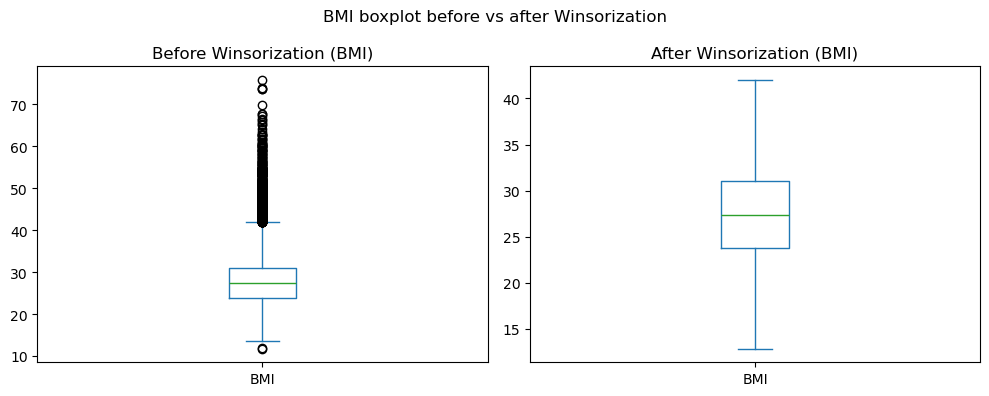

[Saved] figs/asisleep_hist_before_after.png


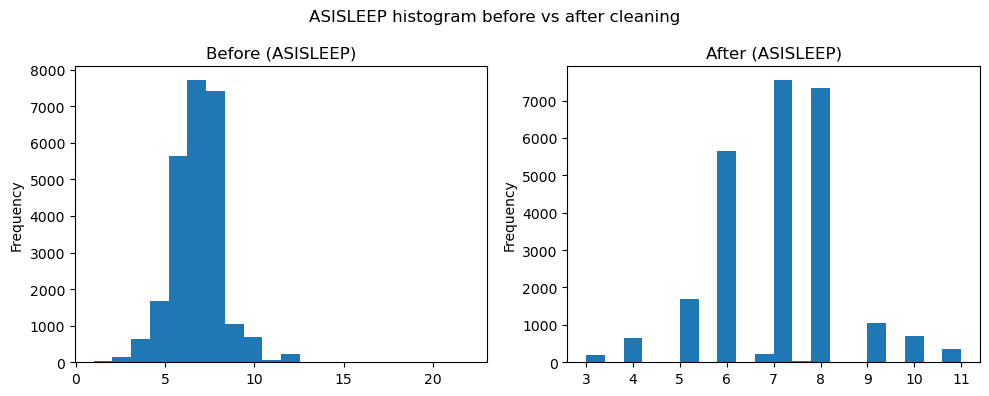

[Saved] figs/beddayr_hist_before_after.png


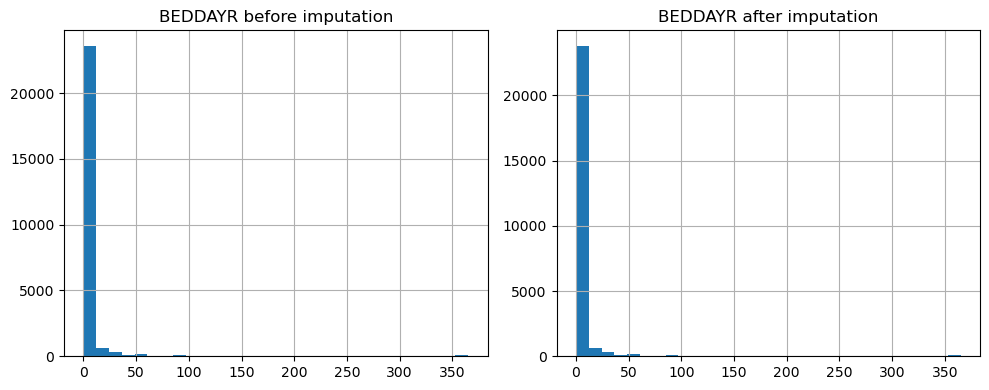

[Saved] figs/paineck_after.png


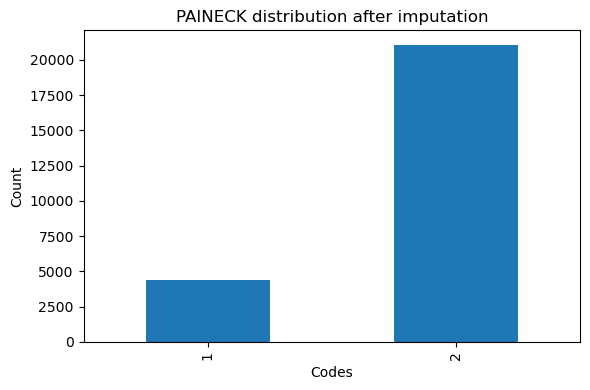

[Saved] figs/doinglwa_after.png


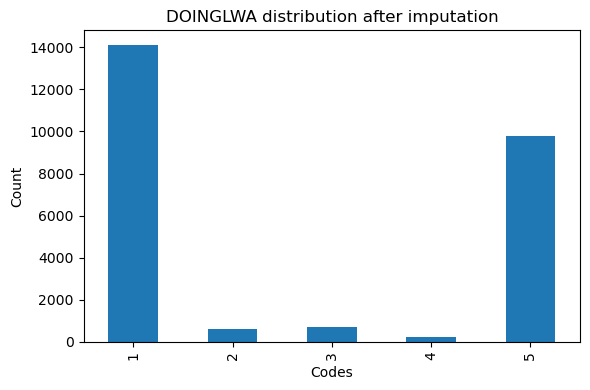

[Saved] figs/amigr_before_after.png


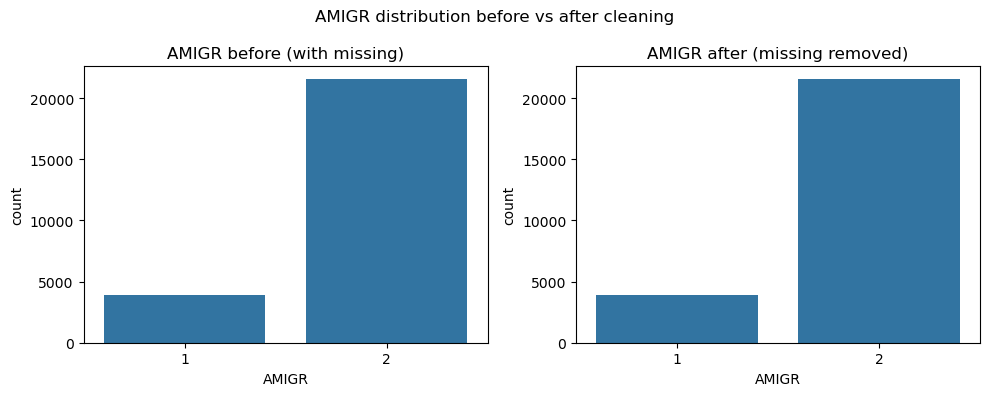

In [15]:
# ---------------------------
# 9) Figures — report-ready
# ---------------------------

# (a) BMI box: before vs after winsorization
if "BMI" in df_before_winsor.columns and "BMI" in df_imp.columns:
    fig, axes = plt.subplots(1,2, figsize=(10,4))
    df_before_winsor["BMI"].plot(kind="box", ax=axes[0], title="Before Winsorization (BMI)")
    df_imp["BMI"].plot(kind="box", ax=axes[1], title="After Winsorization (BMI)")
    fig.suptitle("BMI boxplot before vs after Winsorization")
    plt.tight_layout(); savefig("bmi_winsor_box.png"); plt.show()

# (b) ASISLEEP histogram: before vs after cleaning
if "ASISLEEP" in df_before_winsor.columns and "ASISLEEP" in df_imp.columns:
    fig, axes = plt.subplots(1,2, figsize=(10,4))
    df_before_winsor["ASISLEEP"].plot(kind="hist", bins=20, ax=axes[0], title="Before (ASISLEEP)")
    df_imp["ASISLEEP"].plot(kind="hist", bins=20, ax=axes[1], title="After (ASISLEEP)")
    fig.suptitle("ASISLEEP histogram before vs after cleaning")
    plt.tight_layout(); savefig("asisleep_hist_before_after.png"); plt.show()

# (c) BEDDAYR histogram: before vs after imputation
if "BEDDAYR" in df_before_imp.columns and "BEDDAYR" in df_imp.columns:
    fig, axes = plt.subplots(1,2, figsize=(10,4))
    df_before_imp["BEDDAYR"].hist(ax=axes[0], bins=30); axes[0].set_title("BEDDAYR before imputation")
    df_imp["BEDDAYR"].hist(ax=axes[1], bins=30);         axes[1].set_title("BEDDAYR after imputation")
    plt.tight_layout(); savefig("beddayr_hist_before_after.png"); plt.show()

# (d) Example categorical distributions after imputation
for cat in ["PAINECK", "DOINGLWA"]:
    if cat in df_imp.columns:
        plt.figure(figsize=(6,4))
        df_imp[cat].value_counts(dropna=False).sort_index().plot(kind="bar")
        plt.title(f"{cat} distribution after imputation")
        plt.ylabel("Count"); plt.xlabel("Codes")
        plt.tight_layout(); savefig(f"{cat.lower()}_after.png"); plt.show()

# (e) AMIGR before vs after (left = with missing, right = after drop)
import seaborn as sns
fig, axes = plt.subplots(1,2, figsize=(10,4))
if TARGET_COL in df_clean.columns:
    sns.countplot(x=TARGET_COL, data=df_clean, ax=axes[0]); axes[0].set_title("AMIGR before (with missing)")
sns.countplot(x=TARGET_COL, data=df_imp, ax=axes[1]);       axes[1].set_title("AMIGR after (missing removed)")
fig.suptitle("AMIGR distribution before vs after cleaning")
plt.tight_layout(); savefig("amigr_before_after.png"); plt.show()


In [16]:
print("Missing before:", df_clean["BEDDAYR"].isna().sum())
print("Missing after :", df_imp["BEDDAYR"].isna().sum())

Missing before: 225
Missing after : 0


In [17]:
# ---------------------------
# 10) Final completeness table (for the report)
# ---------------------------
final_summary = pd.DataFrame({
    "Remaining NaNs": df_imp.isna().sum(),
    "Unique Values":  df_imp.nunique(),
    "Data Type":      df_imp.dtypes.astype(str),
})
final_summary.to_csv(OUT_DIR / "cleaning_summary_table.csv")
print("Saved ->", OUT_DIR / "cleaning_summary_table.csv")
final_summary.head(12)

Saved -> prep_outputs/cleaning_summary_table.csv


,Remaining NaNs,Unique Values,Data Type
RID,0,25403,int64
AMIGR,0,2,Int64
AGE_P,0,68,float64
AHAYFYR,0,2,int64
AHCSYR1,0,2,int64
ANX_1,0,5,int64
ANX_2,0,2,int64
ANX_3R,0,3,int64
ARX12_2,0,2,int64
ARX12_3,0,2,int64
